# DBScan Cosine


In [2]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, Normalizer

# BAGIAN A: LOAD DATA & PREPROCESSING

df = pd.read_csv('data/marketing_campaign.csv', sep='\t')

kolom_fitur = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]
kolom_ada = [k for k in kolom_fitur if k in df.columns]
df_fitur  = df[kolom_ada].dropna()

kolom_teks = df_fitur.select_dtypes(include='object').columns.tolist()
if kolom_teks:
    df_fitur = pd.get_dummies(df_fitur, columns=kolom_teks, drop_first=True)

# Standardisasi biasa
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_fitur)

# L2 Normalization — WAJIB untuk Cosine distance di DBSCAN
X_l2 = Normalizer(norm='l2').fit_transform(X_scaled)

print(f"Data siap | Shape: {X_l2.shape} | Baris: {len(df_fitur)}")
print("L2 Normalization diterapkan untuk Cosine distance.")

EPS         = 0.15   # lebih kecil dari Euclidean/Manhattan karena rentang Cosine berbeda
MIN_SAMPLES = 8

Data siap | Shape: (2216, 16) | Baris: 2216
L2 Normalization diterapkan untuk Cosine distance.


In [3]:
# BAGIAN B: DBSCAN COSINE — Latih + Ukur Performa

print("\n" + "="*54)
print("  DBSCAN — METRIK: COSINE")
print(f"  Parameter: eps={EPS}, min_samples={MIN_SAMPLES}")
print("="*54)

# Mulai ukur memori dan waktu
tracemalloc.start()
t_mulai = time.time()

# DBSCAN dengan metric cosine langsung (didukung sklearn)
db_cosine  = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='cosine')
lbl_cosine = db_cosine.fit_predict(X_l2)

# Hentikan ukur
t_selesai = time.time()
_, mem_puncak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Hitung statistik
n_klaster_c  = len(set(lbl_cosine)) - (1 if -1 in lbl_cosine else 0)
n_noise_c    = int((lbl_cosine == -1).sum())
pct_noise_c  = n_noise_c / len(lbl_cosine) * 100
mask_valid_c = lbl_cosine != -1

if mask_valid_c.sum() > 1 and n_klaster_c >= 2:
    sil_cosine = silhouette_score(X_l2[mask_valid_c], lbl_cosine[mask_valid_c],
                                  metric='cosine')
    sil_c_str  = f"{sil_cosine:.4f}"
else:
    sil_cosine = None
    sil_c_str  = "N/A (klaster < 2)"

# Tampilkan Evaluasi
print(f"  Jumlah Klaster    : {n_klaster_c}")
print(f"  Titik Noise (-1)  : {n_noise_c} ({pct_noise_c:.1f}%)")
print(f"  Waktu Eksekusi    : {t_selesai - t_mulai:.4f} detik")
print(f"  Memori Puncak     : {mem_puncak/1024:.2f} KB ({mem_puncak/1024**2:.4f} MB)")
print(f"  Silhouette Score  : {sil_c_str}")
print("="*54)


  DBSCAN — METRIK: COSINE
  Parameter: eps=0.15, min_samples=8
  Jumlah Klaster    : 5
  Titik Noise (-1)  : 617 (27.8%)
  Waktu Eksekusi    : 0.3687 detik
  Memori Puncak     : 96628.66 KB (94.3639 MB)
  Silhouette Score  : 0.2801


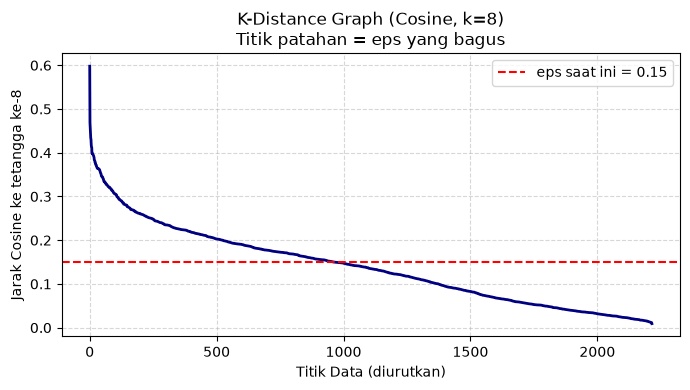

K-distance graph disimpan: 'a4_kdistance_cosine.png'


In [4]:
# BAGIAN C: TIPS TUNING EPS (opsional, bisa dijalankan dulu)

from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='cosine')
nn.fit(X_l2)
distances, _ = nn.kneighbors(X_l2)
k_dist       = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(7, 4))
plt.plot(k_dist, color='navy', linewidth=2)
plt.axhline(y=EPS, color='red', linestyle='--', linewidth=1.5,
            label=f'eps saat ini = {EPS}')
plt.title(f'K-Distance Graph (Cosine, k={MIN_SAMPLES})\n'
          'Titik patahan = eps yang bagus')
plt.xlabel('Titik Data (diurutkan)')
plt.ylabel(f'Jarak Cosine ke tetangga ke-{MIN_SAMPLES}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('a4_kdistance_cosine.png')
plt.show()
print("K-distance graph disimpan: 'a4_kdistance_cosine.png'")

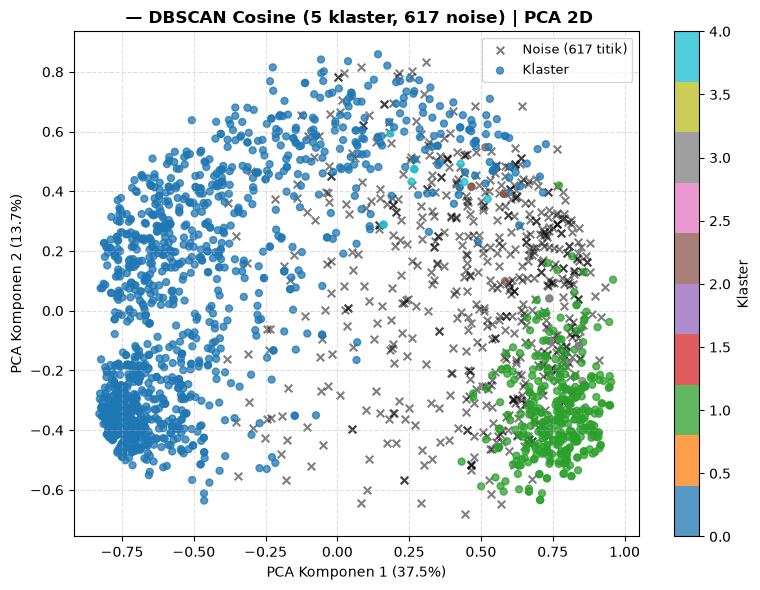

Visualisasi disimpan: 'a4_dbscan_cosine_plot.png'

  RINGKASAN — 
  Metrik        Klaster    Noise   Silhouette
  --------------------------------------------
  Cosine              5      617       0.2801


In [5]:
# BAGIAN D: VISUALISASI PCA

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_l2)   # PCA dari data L2
v1, v2 = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))

mask_noise   = lbl_cosine == -1
mask_klaster = ~mask_noise

# Titik noise → warna hitam, tanda x
plt.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
            c='black', marker='x', s=30, alpha=0.5,
            label=f'Noise ({mask_noise.sum()} titik)')

# Titik klaster → berwarna
if mask_klaster.sum() > 0:
    sc = plt.scatter(X_pca[mask_klaster, 0], X_pca[mask_klaster, 1],
                     c=lbl_cosine[mask_klaster], cmap='tab10', s=25,
                     alpha=0.75, label='Klaster')
    plt.colorbar(sc, label='Klaster')

plt.title(f' — DBSCAN Cosine ({n_klaster_c} klaster, '
          f'{n_noise_c} noise) | PCA 2D',
          fontsize=12, fontweight='bold')
plt.xlabel(f'PCA Komponen 1 ({v1:.1f}%)')
plt.ylabel(f'PCA Komponen 2 ({v2:.1f}%)')
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('a4_dbscan_cosine_plot.png', dpi=150)
plt.show()
print("Visualisasi disimpan: 'a4_dbscan_cosine_plot.png'")

# RINGKASAN
print("\n" + "="*58)
print("  RINGKASAN — ")
print("="*58)
print(f"  {'Metrik':<12} {'Klaster':>8} {'Noise':>8} {'Silhouette':>12}")
print("  " + "-"*44)
print(f"  {'Cosine':<12} {n_klaster_c:>8} {n_noise_c:>8} {sil_c_str:>12}")
print("="*58)